In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SVM_MODEL_PATH = '/content/drive/MyDrive/svm_keystroke_baseline_clean.pkl'
RF_MODEL_PATH  = '/content/drive/MyDrive/rf_keystroke_baseline_clean.pkl'
ZIP_PATH       = '/content/drive/MyDrive/keystroke_clean.zip'
EXTRACT_DIR    = '/content/dataset'

print("Paths set.")

Paths set.


In [ ]:
!pip install librosa scikit-learn numpy matplotlib seaborn soundfile pandas joblib tqdm -q

import os
import zipfile
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported!')

All libraries imported!


In [ ]:
svm_data = joblib.load(SVM_MODEL_PATH)
svm_model  = svm_data['model']
svm_scaler = svm_data['scaler']
le         = svm_data['label_encoder']

rf_data  = joblib.load(RF_MODEL_PATH)
rf_model = rf_data['model']

print("SVM loaded.")
print("RF loaded.")
print("Classes:", list(le.classes_))
print("Number of classes:", len(le.classes_))

SVM loaded.
RF loaded.
Classes: [np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('space'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z')]
Number of classes: 27


In [ ]:
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Dataset extracted!")

Extracting dataset...
Dataset extracted!


In [ ]:
TEST_DIR = Path('/content/dataset/keystroke_clean/data_raw/Test/Test')

print("TEST_DIR exists:", TEST_DIR.exists())
print("labels.csv exists:", (TEST_DIR / 'labels.csv').exists())
print("audio_data exists:", (TEST_DIR / 'audio_data').exists())

TEST_DIR exists: True
labels.csv exists: True
audio_data exists: True


In [ ]:
test_csv = TEST_DIR / 'labels.csv'
test_audio_dir = TEST_DIR / 'audio_data'

test_df = pd.read_csv(test_csv)
test_df['filepath'] = test_df['filename'].apply(lambda x: str(test_audio_dir / x))
test_df['exists'] = test_df['filepath'].apply(os.path.exists)

missing = test_df[~test_df['exists']]
if len(missing) > 0:
    print("Missing files:", len(missing))
    print(missing.head())

test_df = test_df[test_df['exists']].reset_index(drop=True)

test_files = test_df['filepath'].tolist()
test_labels = test_df['key'].tolist()
y_test_clean = le.transform(test_labels)

print("Test set size:", len(test_files))
print(test_df.head())

Test set size: 1600
    filename key original_path  duration_s segment_id  \
0  a_116.wav   a   a/a_116.wav        0.38      a_116   
1  a_120.wav   a   a/a_120.wav        0.38      a_120   
2  a_129.wav   a   a/a_129.wav        0.38      a_129   
3  a_137.wav   a   a/a_137.wav        0.38      a_137   
4  a_158.wav   a   a/a_158.wav        0.38      a_158   

                                            filepath  exists  
0  /content/dataset/keystroke_clean/data_raw/Test...    True  
1  /content/dataset/keystroke_clean/data_raw/Test...    True  
2  /content/dataset/keystroke_clean/data_raw/Test...    True  
3  /content/dataset/keystroke_clean/data_raw/Test...    True  
4  /content/dataset/keystroke_clean/data_raw/Test...    True  


In [ ]:
SAMPLE_RATE = 22050
DURATION    = 0.40
N_MFCC      = 40
N_FFT       = 1024
HOP_LENGTH  = 256

print("Audio config loaded.")

Audio config loaded.


In [ ]:
def load_audio(file_path):
    y, _ = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    target_len = int(SAMPLE_RATE * DURATION)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    return y.astype(np.float32)


def extract_mfcc_from_array(y_audio):
    try:
        target_len = int(SAMPLE_RATE * DURATION)
        if len(y_audio) < target_len:
            y_audio = np.pad(y_audio, (0, target_len - len(y_audio)))
        else:
            y_audio = y_audio[:target_len]

        mfcc = librosa.feature.mfcc(
            y=y_audio,
            sr=SAMPLE_RATE,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std  = np.std(mfcc, axis=1)

        feat = np.concatenate([mfcc_mean, mfcc_std]).astype(np.float32)
        return feat
    except Exception as e:
        print(f"Feature extraction error: {e}")
        return None

print("Audio loader and MFCC extractor ready.")

Audio loader and MFCC extractor ready.


In [ ]:
print("Extracting MFCC features from official clean test set...")

X_test_clean = []

for fpath in tqdm(test_files, total=len(test_files), desc='Clean Test'):
    y_audio = load_audio(fpath)
    feat = extract_mfcc_from_array(y_audio)
    X_test_clean.append(feat)

X_test_clean = np.array(X_test_clean, dtype=np.float32)

svm_clean_pred = svm_model.predict(svm_scaler.transform(X_test_clean))
rf_clean_pred  = rf_model.predict(X_test_clean)

svm_clean_acc = accuracy_score(y_test_clean, svm_clean_pred)
rf_clean_acc  = accuracy_score(y_test_clean, rf_clean_pred)

print(f"SVM clean test accuracy: {svm_clean_acc * 100:.2f}%")
print(f"RF  clean test accuracy: {rf_clean_acc * 100:.2f}%")

Extracting MFCC features from official clean test set...


Clean Test: 100%|██████████| 1600/1600 [00:28<00:00, 55.46it/s] 


SVM clean test accuracy: 96.06%
RF  clean test accuracy: 90.62%


In [ ]:
def dft_attack(y_audio, epsilon=0.1, top_k_ratio=0.1, mode='top_k', seed=None):
    if seed is not None:
        np.random.seed(seed)

    Y = np.fft.rfft(y_audio)
    magnitudes = np.abs(Y)
    phases = np.angle(Y)

    n_bins = len(Y)
    k = max(1, int(n_bins * top_k_ratio))

    if mode == 'top_k':
        target_bins = np.argsort(magnitudes)[-k:]
    elif mode == 'random':
        target_bins = np.random.choice(n_bins, k, replace=False)
    elif mode == 'low_freq':
        target_bins = np.arange(k)
    elif mode == 'high_freq':
        target_bins = np.arange(n_bins - k, n_bins)
    else:
        raise ValueError(f'Unknown mode: {mode}')

    Y_adv = Y.copy()
    max_mag = magnitudes.max() if magnitudes.max() > 0 else 1.0

    delta_mag = epsilon * max_mag * np.random.uniform(-1, 1, size=k)
    delta_phase = epsilon * np.pi * np.random.uniform(-1, 1, size=k)

    new_mags = np.maximum(0, magnitudes[target_bins] + delta_mag)
    new_phases = phases[target_bins] + delta_phase

    Y_adv[target_bins] = new_mags * np.exp(1j * new_phases)

    y_adv = np.fft.irfft(Y_adv, n=len(y_audio))
    y_adv = np.clip(y_adv, -1.0, 1.0).astype(np.float32)

    noise = y_adv - y_audio
    signal_power = np.mean(y_audio ** 2)
    noise_power = np.mean(noise ** 2)
    snr = 10 * np.log10(signal_power / (noise_power + 1e-10))

    return y_adv, snr

print("DFT attack function ready.")

DFT attack function ready.


In [ ]:
demo_file = test_files[0]
demo_label = test_labels[0]

y_orig = load_audio(demo_file)
DEMO_EPSILON = 0.15
y_adv, snr = dft_attack(y_orig, epsilon=DEMO_EPSILON, mode='top_k', seed=0)

print(f'Label: {demo_label}')
print(f'Epsilon: {DEMO_EPSILON}')
print(f'SNR after attack: {snr:.2f} dB')

Label: a
Epsilon: 0.15
SNR after attack: 4.75 dB


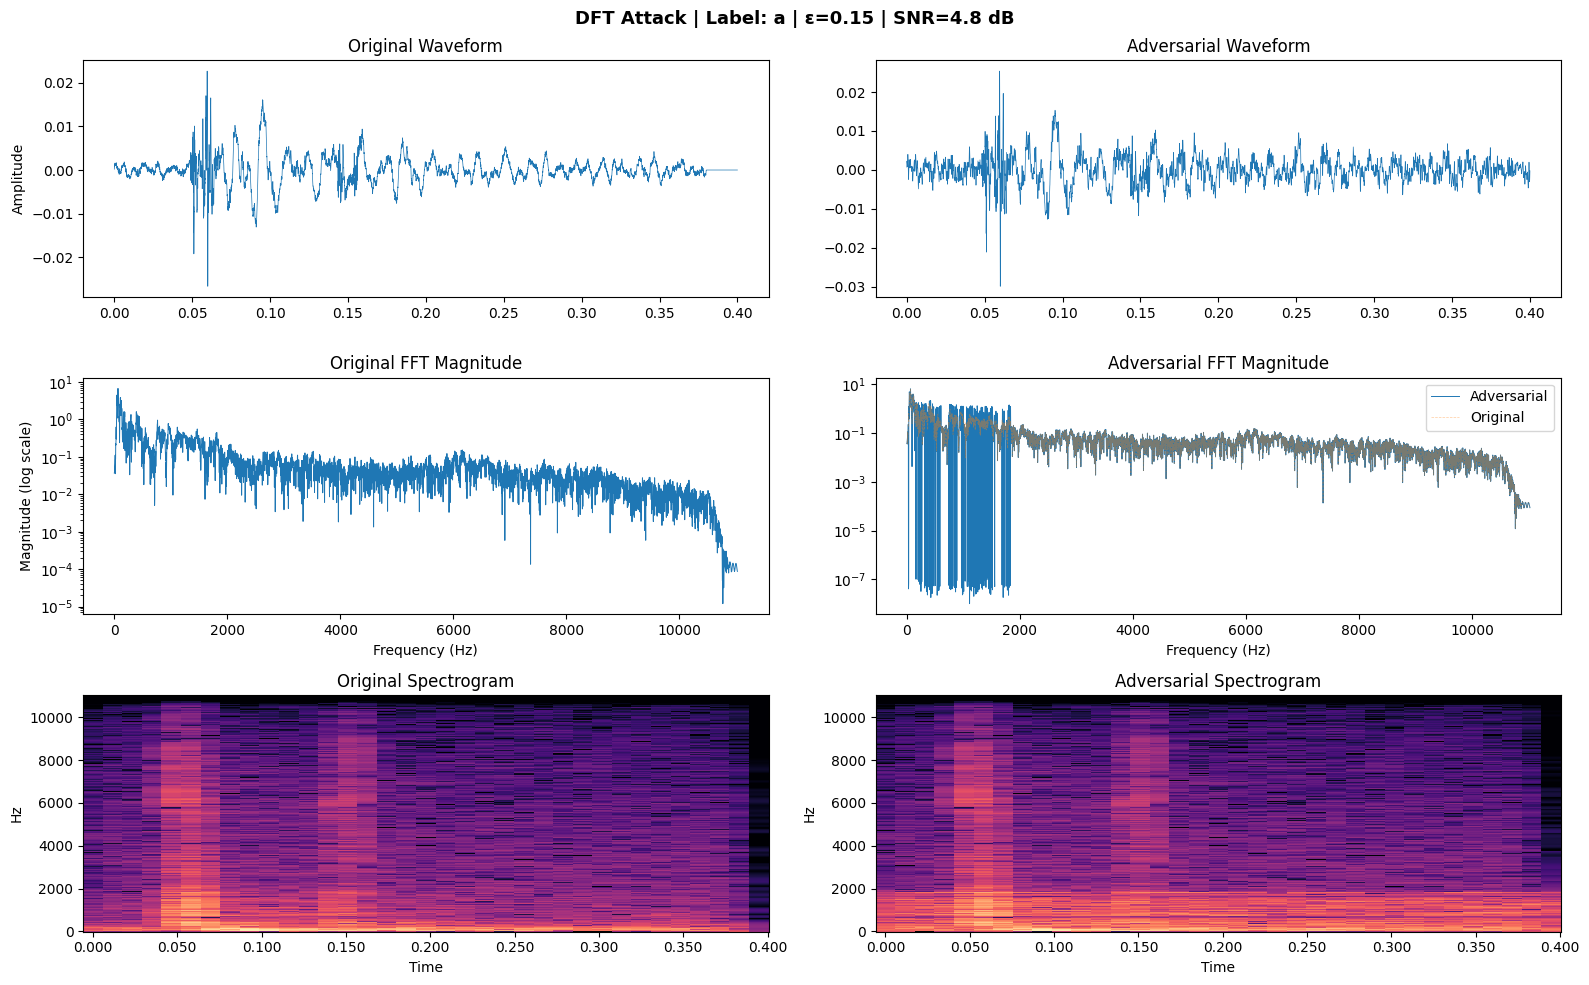

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle(
    f'DFT Attack | Label: {demo_label} | ε={DEMO_EPSILON} | SNR={snr:.1f} dB',
    fontsize=13,
    fontweight='bold'
)

t = np.linspace(0, DURATION, len(y_orig))

axes[0,0].plot(t, y_orig, linewidth=0.5)
axes[0,0].set_title('Original Waveform')
axes[0,0].set_ylabel('Amplitude')

axes[0,1].plot(t, y_adv, linewidth=0.5)
axes[0,1].set_title('Adversarial Waveform')

freqs = np.fft.rfftfreq(len(y_orig), 1 / SAMPLE_RATE)
Y_orig = np.abs(np.fft.rfft(y_orig))
Y_adv_mag = np.abs(np.fft.rfft(y_adv))

axes[1,0].semilogy(freqs, Y_orig + 1e-8, linewidth=0.7)
axes[1,0].set_title('Original FFT Magnitude')
axes[1,0].set_xlabel('Frequency (Hz)')
axes[1,0].set_ylabel('Magnitude (log scale)')

axes[1,1].semilogy(freqs, Y_adv_mag + 1e-8, linewidth=0.7, label='Adversarial')
axes[1,1].semilogy(freqs, Y_orig + 1e-8, linewidth=0.5, alpha=0.4, linestyle='--', label='Original')
axes[1,1].set_title('Adversarial FFT Magnitude')
axes[1,1].set_xlabel('Frequency (Hz)')
axes[1,1].legend()

D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig, n_fft=N_FFT)), ref=np.max)
D_adv  = librosa.amplitude_to_db(np.abs(librosa.stft(y_adv,  n_fft=N_FFT)), ref=np.max)

librosa.display.specshow(D_orig, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='hz', ax=axes[2,0])
axes[2,0].set_title('Original Spectrogram')

librosa.display.specshow(D_adv, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='hz', ax=axes[2,1])
axes[2,1].set_title('Adversarial Spectrogram')

plt.tight_layout()
plt.show()

In [ ]:
EPSILONS = [0.005, 0.01, 0.02, 0.05,]
ATTACK_MODES = ['random']
TOP_K_RATIO = 0.1

print("Attack settings ready.")

Attack settings ready.


In [ ]:
def run_attack(model, scaler, files, true_labels, epsilon, mode, model_name):
    adv_feats = []
    adv_labels = []
    snrs = []

    for i, (fpath, label) in enumerate(zip(files, true_labels)):
        try:
            y_orig = load_audio(fpath)

            if epsilon == 0.0:
                y_attacked = y_orig
                snr = float('inf')
            else:
                y_attacked, snr = dft_attack(
                    y_orig,
                    epsilon=epsilon,
                    top_k_ratio=TOP_K_RATIO,
                    mode=mode,
                    seed=i
                )

            feat = extract_mfcc_from_array(y_attacked)
            if feat is not None:
                adv_feats.append(feat)
                adv_labels.append(le.transform([label])[0])
                snrs.append(snr)

        except Exception:
            pass

    if len(adv_feats) == 0:
        return None

    X_adv = np.array(adv_feats, dtype=np.float32)
    y_true = np.array(adv_labels)

    if model_name == 'SVM':
        X_input = scaler.transform(X_adv)
    else:
        X_input = X_adv

    y_pred = model.predict(X_input)
    acc = accuracy_score(y_true, y_pred)

    finite_snrs = [s for s in snrs if np.isfinite(s)]
    mean_snr = np.mean(finite_snrs) if finite_snrs else float('inf')

    return {
        'model': model_name,
        'mode': mode,
        'epsilon': epsilon,
        'accuracy': acc,
        'mean_snr': mean_snr,
        'y_true': y_true,
        'y_pred': y_pred
    }

print("Attack evaluation function ready.")

Attack evaluation function ready.


In [ ]:
results = []

for mode in ATTACK_MODES:
    print(f'\nRunning attack mode: {mode}')
    for eps in tqdm(EPSILONS, desc=mode):
        r_svm = run_attack(svm_model, svm_scaler, test_files, test_labels, eps, mode, 'SVM')
        r_rf  = run_attack(rf_model, None, test_files, test_labels, eps, mode, 'RandomForest')

        if r_svm is not None:
            results.append(r_svm)
        if r_rf is not None:
            results.append(r_rf)

print("\nAll attacks complete!")


Running attack mode: random


random: 100%|██████████| 4/4 [02:08<00:00, 32.22s/it]


All attacks complete!


In [ ]:
rows = []

for r in results:
    clean_acc = svm_clean_acc if r['model'] == 'SVM' else rf_clean_acc
    drop = (clean_acc - r['accuracy']) * 100

    rows.append({
        'Model': r['model'],
        'Attack Mode': r['mode'],
        'Epsilon': r['epsilon'],
        'Accuracy (%)': round(r['accuracy'] * 100, 2),
        'Acc Drop (%)': round(drop, 2),
        'Mean SNR (dB)': round(r['mean_snr'], 1) if np.isfinite(r['mean_snr']) else 'inf'
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

       Model Attack Mode  Epsilon  Accuracy (%)  Acc Drop (%)  Mean SNR (dB)
         SVM      random    0.005         92.00          4.06           34.0
RandomForest      random    0.005         85.00          5.63           34.0
         SVM      random    0.010         82.44         13.62           28.5
RandomForest      random    0.010         66.88         23.75           28.5
         SVM      random    0.020         47.50         48.56           23.1
RandomForest      random    0.020         45.19         45.44           23.1
         SVM      random    0.050         12.06         84.00           15.8
RandomForest      random    0.050         32.12         58.50           15.8


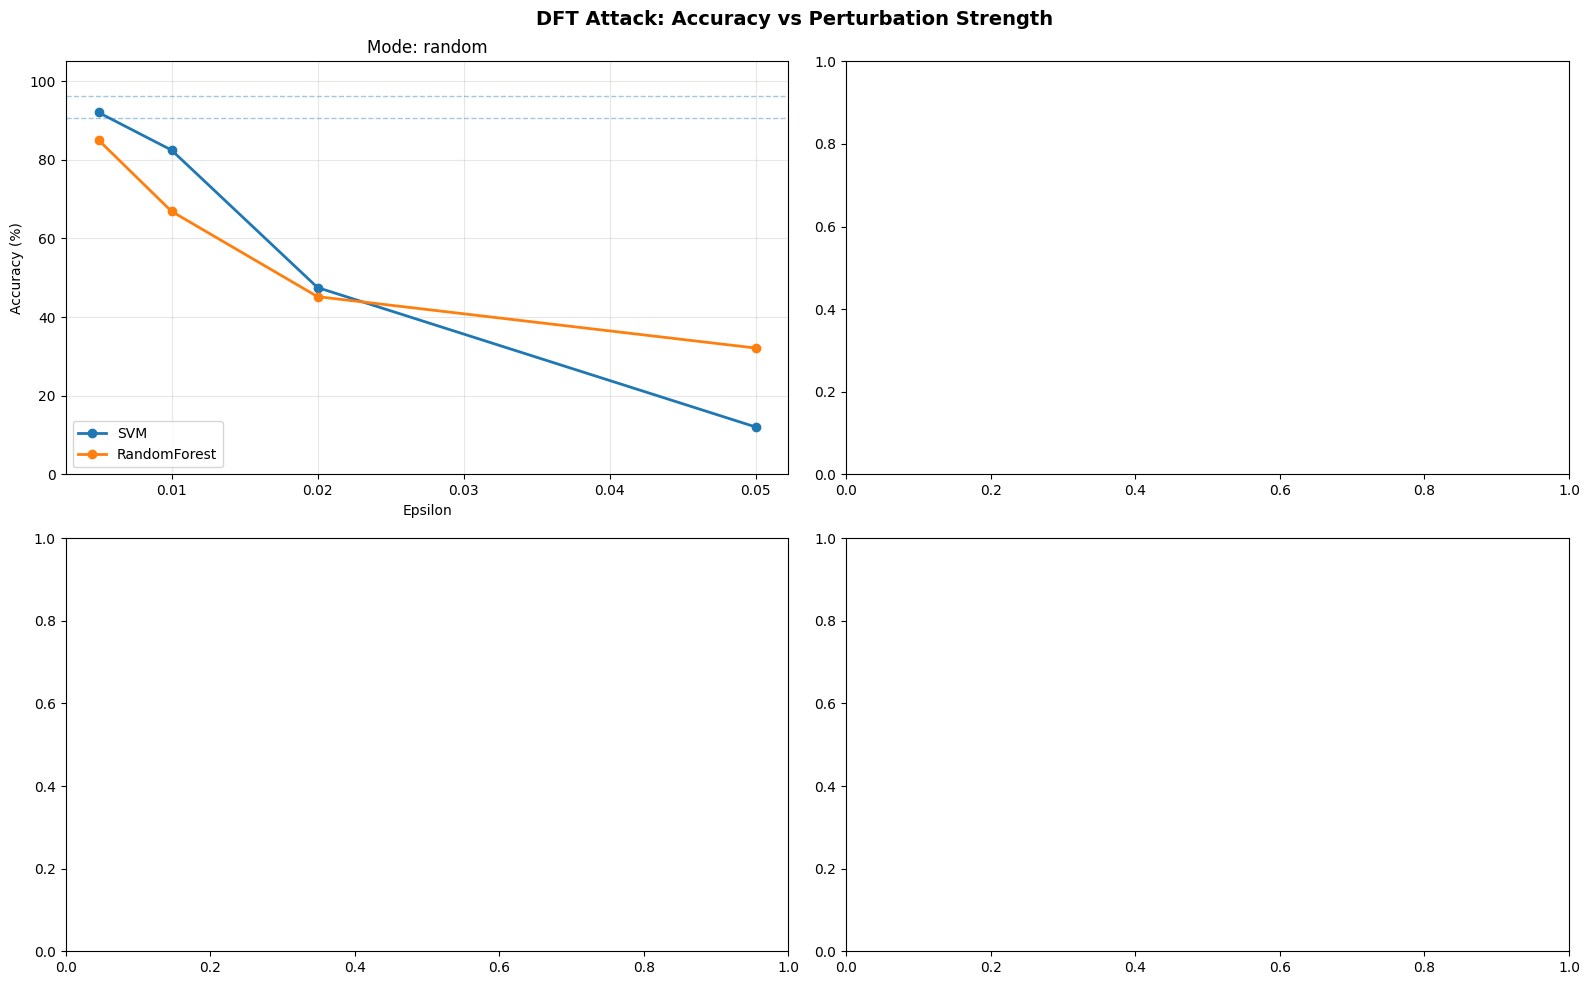

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, mode in enumerate(ATTACK_MODES):
    ax = axes[i]

    for model_name in ['SVM', 'RandomForest']:
        clean_acc = svm_clean_acc if model_name == 'SVM' else rf_clean_acc
        mode_res = [r for r in results if r['model'] == model_name and r['mode'] == mode]

        eps_vals = [r['epsilon'] for r in mode_res]
        acc_vals = [r['accuracy'] * 100 for r in mode_res]

        ax.plot(eps_vals, acc_vals, marker='o', linewidth=2, markersize=6, label=model_name)
        ax.axhline(clean_acc * 100, linestyle='--', linewidth=1, alpha=0.4)

    ax.set_title(f'Mode: {mode}')
    ax.set_xlabel('Epsilon')
    ax.set_ylabel('Accuracy (%)')
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_ylim(0, 105)

plt.suptitle('DFT Attack: Accuracy vs Perturbation Strength', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

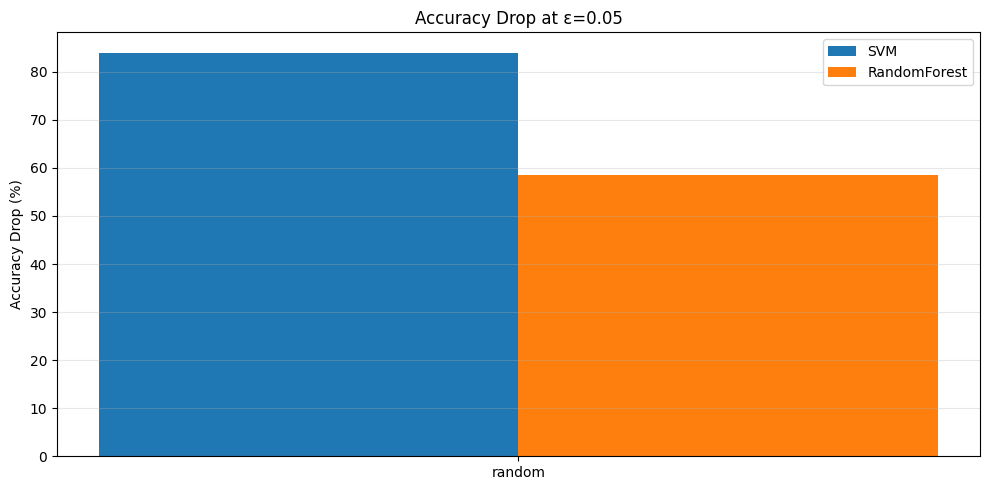

In [ ]:
MAX_EPS = max(EPSILONS)
strong_res = [r for r in results if r['epsilon'] == MAX_EPS]

mode_labels = []
svm_drops = []
rf_drops = []

for mode in ATTACK_MODES:
    svm_r = next((r for r in strong_res if r['model'] == 'SVM' and r['mode'] == mode), None)
    rf_r  = next((r for r in strong_res if r['model'] == 'RandomForest' and r['mode'] == mode), None)

    if svm_r and rf_r:
        mode_labels.append(mode)
        svm_drops.append((svm_clean_acc - svm_r['accuracy']) * 100)
        rf_drops.append((rf_clean_acc - rf_r['accuracy']) * 100)

x = np.arange(len(mode_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, svm_drops, w, label='SVM')
ax.bar(x + w/2, rf_drops,  w, label='RandomForest')

ax.set_title(f'Accuracy Drop at ε={MAX_EPS}')
ax.set_ylabel('Accuracy Drop (%)')
ax.set_xticks(x)
ax.set_xticklabels(mode_labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_attack = next(
    (r for r in results if r['model'] == 'SVM' and r['mode'] == 'top_k' and r['epsilon'] == MAX_EPS),
    None
)

if best_attack:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    def plot_cm(y_true, y_pred, title, ax):
        cm = confusion_matrix(y_true, y_pred)
        pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        sns.heatmap(
            pct,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=ax,
            linewidths=0.5
        )
        ax.set_title(title)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    plot_cm(y_test_clean, svm_clean_pred, f'SVM Clean (Acc={svm_clean_acc*100:.1f}%)', axes[0])
    plot_cm(best_attack['y_true'], best_attack['y_pred'],
            f'SVM top_k ε={MAX_EPS} (Acc={best_attack["accuracy"]*100:.1f}%)', axes[1])

    plt.tight_layout()
    plt.show()

In [ ]:
for model_name in ['SVM', 'RandomForest']:
    attack_res = next(
        (r for r in results if r['model'] == model_name and r['mode'] == 'top_k' and r['epsilon'] == MAX_EPS),
        None
    )

    if attack_res:
        print(f'\n{model_name} — Per-class report after DFT attack (top_k, ε={MAX_EPS})')
        print(classification_report(
            attack_res['y_true'],
            attack_res['y_pred'],
            target_names=le.classes_
        ))

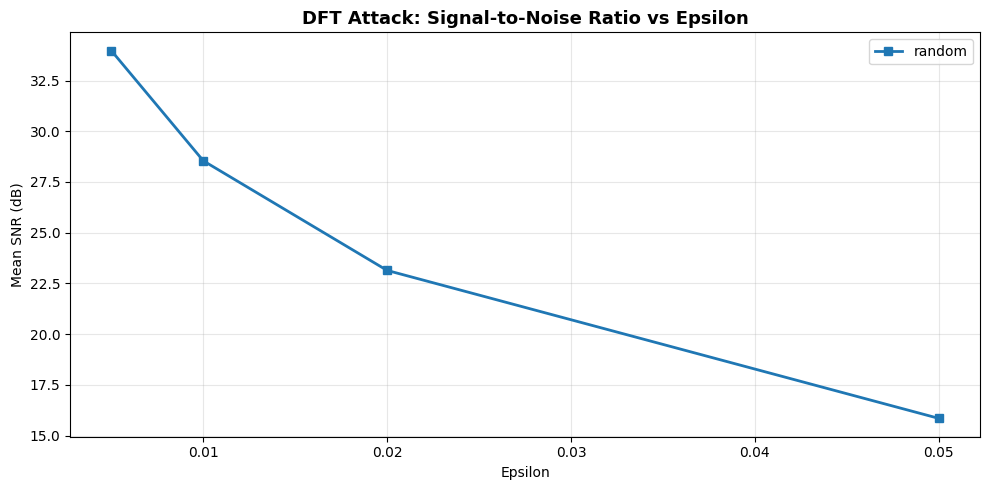

In [ ]:
plt.figure(figsize=(10, 5))

for mode in ATTACK_MODES:
    mode_res = [
        r for r in results
        if r['model'] == 'SVM' and r['mode'] == mode and r['epsilon'] > 0
    ]

    eps_vals = [r['epsilon'] for r in mode_res]
    snr_vals = [r['mean_snr'] for r in mode_res]

    if eps_vals:
        plt.plot(eps_vals, snr_vals, marker='s', linewidth=2, label=mode)

plt.title('DFT Attack: Signal-to-Noise Ratio vs Epsilon', fontsize=13, fontweight='bold')
plt.xlabel('Epsilon')
plt.ylabel('Mean SNR (dB)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print('=' * 60)
print('DFT ATTACK — FINAL RESULTS SUMMARY')
print('=' * 60)

print('\nClean Accuracy')
print(f'SVM           : {svm_clean_acc * 100:.2f}%')
print(f'Random Forest : {rf_clean_acc * 100:.2f}%')

print(f'\nStrongest epsilon evaluated: ε={MAX_EPS}')

for model_name in ['SVM', 'RandomForest']:
    worst = min(
        [r for r in results if r['model'] == model_name and r['epsilon'] == MAX_EPS],
        key=lambda r: r['accuracy'],
        default=None
    )

    if worst:
        clean = svm_clean_acc if model_name == 'SVM' else rf_clean_acc
        drop = (clean - worst['accuracy']) * 100

        print(f'{model_name:<15}: worst mode = {worst["mode"]:<10} | '
              f'adv acc = {worst["accuracy"]*100:.2f}% | '
              f'drop = {drop:.2f}% | '
              f'SNR = {worst["mean_snr"]:.2f} dB')

print('=' * 60)

DFT ATTACK — FINAL RESULTS SUMMARY

Clean Accuracy
SVM           : 96.06%
Random Forest : 90.62%

Strongest epsilon evaluated: ε=0.05
SVM            : worst mode = random     | adv acc = 12.06% | drop = 84.00% | SNR = 15.85 dB
RandomForest   : worst mode = random     | adv acc = 32.12% | drop = 58.50% | SNR = 15.85 dB


In [ ]:
rows = []

ATTACK_TYPES = ['FGSM', 'BIM', 'PGD', 'DFT']

for model_name in ['SVM', 'RandomForest']:
    clean_acc = svm_clean_acc if model_name == 'SVM' else rf_clean_acc

    for attack in ATTACK_TYPES:
        if attack != 'DFT':
            # Fill placeholders for unsupported attacks
            rows.append({
                'model_name'          : model_name,
                'clean_accuracy'      : round(clean_acc * 100, 2),
                'attack_type'         : attack,
                'epsilon'             : '--',
                'adversarial_accuracy': '--',
                'relative_accuracy'   : '--',
                'ASR'                 : '--'
            })
        else:
            # Fill real DFT results
            for r in results:
                if r['model'] == model_name:
                    adv_acc = r['accuracy']

                    relative_acc = (adv_acc / clean_acc) * 100
                    asr          = 100 - relative_acc

                    rows.append({
                        'model_name'          : model_name,
                        'clean_accuracy'      : round(clean_acc * 100, 2),
                        'attack_type'         : r['mode'],   # top_k, random, etc.
                        'epsilon'             : r['epsilon'],
                        'adversarial_accuracy': round(adv_acc * 100, 2),
                        'relative_accuracy'   : round(relative_acc, 2),
                        'ASR'                 : round(asr, 2)
                    })

df_final = pd.DataFrame(rows)

# Sort nicely
df_final = df_final.sort_values(
    by=['model_name', 'attack_type', 'epsilon'],
    ignore_index=True
)

print("Preview of final table:")
print(df_final.head(30))

df_final

Preview of final table:
      model_name  clean_accuracy attack_type epsilon adversarial_accuracy  \
0   RandomForest           90.62         BIM      --                   --   
1   RandomForest           90.62        FGSM      --                   --   
2   RandomForest           90.62         PGD      --                   --   
3   RandomForest           90.62      random   0.005                 85.0   
4   RandomForest           90.62      random    0.01                66.88   
5   RandomForest           90.62      random    0.02                45.19   
6   RandomForest           90.62      random    0.05                32.12   
7            SVM           96.06         BIM      --                   --   
8            SVM           96.06        FGSM      --                   --   
9            SVM           96.06         PGD      --                   --   
10           SVM           96.06      random   0.005                 92.0   
11           SVM           96.06      random    0.01

,model_name,clean_accuracy,attack_type,epsilon,adversarial_accuracy,relative_accuracy,ASR
0,RandomForest,90.62,BIM,--,--,--,--
1,RandomForest,90.62,FGSM,--,--,--,--
2,RandomForest,90.62,PGD,--,--,--,--
3,RandomForest,90.62,random,0.005,85.0,93.79,6.21
4,RandomForest,90.62,random,0.01,66.88,73.79,26.21
5,RandomForest,90.62,random,0.02,45.19,49.86,50.14
6,RandomForest,90.62,random,0.05,32.12,35.45,64.55
7,SVM,96.06,BIM,--,--,--,--
8,SVM,96.06,FGSM,--,--,--,--
9,SVM,96.06,PGD,--,--,--,--


In [ ]:
df_final.to_csv('/content/drive/MyDrive/final_attack_table.csv', index=False)
print("Saved to Drive")

Saved to Drive


In [ ]:
summary_rows = []

for r in results:
    model_name = r['model']
    clean_acc = svm_clean_acc if model_name == 'SVM' else rf_clean_acc
    adv_acc = r['accuracy']

    relative_acc = (adv_acc / clean_acc) * 100 if clean_acc > 0 else 0.0
    asr = 100 - relative_acc

    attack_label = f"DFT-{r['mode']}"

    summary_rows.append({
        'model_name': model_name,
        'Clean accuracy': round(clean_acc * 100, 2),
        'attack type': attack_label,
        'epsilon': r['epsilon'],
        'adversarial accuracy': round(adv_acc * 100, 2),
        'relative accuracy': round(relative_acc, 2),
        'ASR': round(asr, 2)
    })

df_dft_summary = pd.DataFrame(summary_rows)
df_dft_summary = df_dft_summary.sort_values(
    by=['model_name', 'attack type', 'epsilon'],
    ignore_index=True
)

print("DFT summary table:")
print(df_dft_summary.head(20))

DFT summary table:
     model_name  Clean accuracy attack type  epsilon  adversarial accuracy  \
0  RandomForest           90.62  DFT-random    0.005                 85.00   
1  RandomForest           90.62  DFT-random    0.010                 66.88   
2  RandomForest           90.62  DFT-random    0.020                 45.19   
3  RandomForest           90.62  DFT-random    0.050                 32.12   
4           SVM           96.06  DFT-random    0.005                 92.00   
5           SVM           96.06  DFT-random    0.010                 82.44   
6           SVM           96.06  DFT-random    0.020                 47.50   
7           SVM           96.06  DFT-random    0.050                 12.06   

   relative accuracy    ASR  
0              93.79   6.21  
1              73.79  26.21  
2              49.86  50.14  
3              35.45  64.55  
4              95.77   4.23  
5              85.82  14.18  
6              49.45  50.55  
7              12.56  87.44  


In [ ]:
from sklearn.metrics import classification_report

classwise_rows = []

for r in results:
    model_name = r['model']
    clean_acc = svm_clean_acc if model_name == 'SVM' else rf_clean_acc
    adv_acc = r['accuracy']

    relative_acc = (adv_acc / clean_acc) * 100 if clean_acc > 0 else 0.0
    asr = 100 - relative_acc

    attack_label = f"DFT-{r['mode']}"

    report = classification_report(
        r['y_true'],
        r['y_pred'],
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )

    for class_label, metrics in report.items():
        if isinstance(metrics, dict):
            classwise_rows.append({
                'model_name': model_name,
                'Clean accuracy': round(clean_acc * 100, 2),
                'attack type': attack_label,
                'epsilon': r['epsilon'],
                'class_label': class_label,
                'precision': round(metrics.get('precision', 0.0), 4),
                'recall': round(metrics.get('recall', 0.0), 4),
                'f1-score': round(metrics.get('f1-score', 0.0), 4),
                'support': int(metrics.get('support', 0)) if metrics.get('support', 0) is not None else 0,
                'adversarial accuracy': round(adv_acc * 100, 2),
                'relative accuracy': round(relative_acc, 2),
                'ASR': round(asr, 2)
            })
        else:
            # handles the plain 'accuracy' scalar in classification_report
            if class_label == 'accuracy':
                classwise_rows.append({
                    'model_name': model_name,
                    'Clean accuracy': round(clean_acc * 100, 2),
                    'attack type': attack_label,
                    'epsilon': r['epsilon'],
                    'class_label': 'accuracy',
                    'precision': round(metrics, 4),
                    'recall': round(metrics, 4),
                    'f1-score': round(metrics, 4),
                    'support': 0,
                    'adversarial accuracy': round(adv_acc * 100, 2),
                    'relative accuracy': round(relative_acc, 2),
                    'ASR': round(asr, 2)
                })

df_dft_classwise = pd.DataFrame(classwise_rows)
df_dft_classwise = df_dft_classwise.sort_values(
    by=['model_name', 'attack type', 'epsilon', 'class_label'],
    ignore_index=True
)

print("DFT class-wise table:")
print(df_dft_classwise.head(30))

DFT class-wise table:
      model_name  Clean accuracy attack type  epsilon   class_label  \
0   RandomForest           90.62  DFT-random    0.005             a   
1   RandomForest           90.62  DFT-random    0.005      accuracy   
2   RandomForest           90.62  DFT-random    0.005             b   
3   RandomForest           90.62  DFT-random    0.005             c   
4   RandomForest           90.62  DFT-random    0.005             d   
5   RandomForest           90.62  DFT-random    0.005             e   
6   RandomForest           90.62  DFT-random    0.005             f   
7   RandomForest           90.62  DFT-random    0.005             g   
8   RandomForest           90.62  DFT-random    0.005             h   
9   RandomForest           90.62  DFT-random    0.005             i   
10  RandomForest           90.62  DFT-random    0.005             j   
11  RandomForest           90.62  DFT-random    0.005             k   
12  RandomForest           90.62  DFT-random    0.005  

In [ ]:
summary_path = '/content/drive/MyDrive/dft_summary_svm_rf.csv'
classwise_path = '/content/drive/MyDrive/dft_classwise_svm_rf.csv'

df_dft_summary.to_csv(summary_path, index=False)
df_dft_classwise.to_csv(classwise_path, index=False)

print("Saved summary table to:", summary_path)
print("Saved class-wise table to:", classwise_path)

Saved summary table to: /content/drive/MyDrive/dft_summary_svm_rf.csv
Saved class-wise table to: /content/drive/MyDrive/dft_classwise_svm_rf.csv


In [ ]:
for model_name in ['SVM', 'RandomForest']:
    print("=" * 70)
    print(f"  DFT ATTACKS — {model_name}")
    print("=" * 70)

    clean_acc = svm_clean_acc if model_name == 'SVM' else rf_clean_acc
    print(f"  Clean accuracy : {clean_acc * 100:.2f} %")

    model_summary = df_dft_summary[df_dft_summary['model_name'] == model_name].reset_index(drop=True)
    print("\nSummary:")
    print(model_summary.to_string(index=True))

    print("\nFull class-wise results:")
    model_classwise = df_dft_classwise[df_dft_classwise['model_name'] == model_name].reset_index(drop=True)
    print(model_classwise.to_string(index=True))

    print()

  DFT ATTACKS — SVM
  Clean accuracy : 96.06 %

Summary:
  model_name  Clean accuracy attack type  epsilon  adversarial accuracy  relative accuracy    ASR
0        SVM           96.06  DFT-random    0.005                 92.00              95.77   4.23
1        SVM           96.06  DFT-random    0.010                 82.44              85.82  14.18
2        SVM           96.06  DFT-random    0.020                 47.50              49.45  50.55
3        SVM           96.06  DFT-random    0.050                 12.06              12.56  87.44

Full class-wise results:
    model_name  Clean accuracy attack type  epsilon   class_label  precision  recall  f1-score  support  adversarial accuracy  relative accuracy    ASR
0          SVM           96.06  DFT-random    0.005             a     0.8929  0.8475    0.8696       59                 92.00              95.77   4.23
1          SVM           96.06  DFT-random    0.005      accuracy     0.9200  0.9200    0.9200        0                 92.

In [ ]:
import pandas as pd

model_name_map = {
    'SVM': 'SVM',
    'RandomForest': 'Random Forest'
}

attack_name_map = {
    'DFT-top_k': 'DFT-TopK',
    'DFT-random': 'DFT-Random',
    'DFT-low_freq': 'DFT-LowFreq',
    'DFT-high_freq': 'DFT-HighFreq'
}

model_order = ['SVM', 'Random Forest']

attack_order = [
    'DFT-TopK',
    'DFT-Random',
    'DFT-LowFreq',
    'DFT-HighFreq'
]

In [ ]:
# Clean names for table display
attack_name_map = {
    'DFT-top_k': 'DFT-TopK',
    'DFT-random': 'DFT-Random',
    'DFT-low_freq': 'DFT-LowFreq',
    'DFT-high_freq': 'DFT-HighFreq'
}

model_name_map = {
    'SVM': 'SVM',
    'RandomForest': 'Random Forest'
}

df_summary_clean = df_dft_summary.copy()

df_summary_clean['model_name'] = df_summary_clean['model_name'].replace(model_name_map)
df_summary_clean['attack type'] = df_summary_clean['attack type'].replace(attack_name_map)

# consistent order
attack_order = ['DFT-TopK', 'DFT-Random', 'DFT-LowFreq', 'DFT-HighFreq']
model_order = ['SVM', 'Random Forest']

df_summary_clean['model_name'] = pd.Categorical(
    df_summary_clean['model_name'],
    categories=model_order,
    ordered=True
)

df_summary_clean['attack type'] = pd.Categorical(
    df_summary_clean['attack type'],
    categories=attack_order,
    ordered=True
)

df_summary_clean = df_summary_clean.sort_values(
    by=['model_name', 'attack type', 'epsilon'],
    ignore_index=True
)

summary_csv_path = '/content/drive/MyDrive/dft_summary_svm_rf_clean.csv'
df_summary_clean.to_csv(summary_csv_path, index=False)

print("Saved clean summary CSV to:", summary_csv_path)
df_summary_clean.head(20)

Saved clean summary CSV to: /content/drive/MyDrive/dft_summary_svm_rf_clean.csv


,model_name,Clean accuracy,attack type,epsilon,adversarial accuracy,relative accuracy,ASR
0,SVM,96.06,DFT-Random,0.005,92.00,95.77,4.23
1,SVM,96.06,DFT-Random,0.010,82.44,85.82,14.18
2,SVM,96.06,DFT-Random,0.020,47.50,49.45,50.55
3,SVM,96.06,DFT-Random,0.050,12.06,12.56,87.44
4,Random Forest,90.62,DFT-Random,0.005,85.00,93.79,6.21
5,Random Forest,90.62,DFT-Random,0.010,66.88,73.79,26.21
6,Random Forest,90.62,DFT-Random,0.020,45.19,49.86,50.14
7,Random Forest,90.62,DFT-Random,0.050,32.12,35.45,64.55


In [ ]:
# Desired class order
class_order = [
    'a','b','c','d','e','f','g','h','i','j','k','l','m',
    'n','o','p','q','r','s','space','t','u','v','w','x','y','z',
    'accuracy','macro avg','weighted avg'
]

df_classwise_clean = df_dft_classwise.copy()

df_classwise_clean['model_name'] = df_classwise_clean['model_name'].replace(model_name_map)
df_classwise_clean['attack type'] = df_classwise_clean['attack type'].replace(attack_name_map)

df_classwise_clean['model_name'] = pd.Categorical(
    df_classwise_clean['model_name'],
    categories=model_order,
    ordered=True
)

df_classwise_clean['attack type'] = pd.Categorical(
    df_classwise_clean['attack type'],
    categories=attack_order,
    ordered=True
)

df_classwise_clean['class_label'] = pd.Categorical(
    df_classwise_clean['class_label'],
    categories=class_order,
    ordered=True
)

df_classwise_clean = df_classwise_clean.sort_values(
    by=['model_name', 'attack type', 'epsilon', 'class_label'],
    ignore_index=True
)

classwise_csv_path = '/content/drive/MyDrive/dft_classwise_svm_rf_clean.csv'
df_classwise_clean.to_csv(classwise_csv_path, index=False)

print("Saved clean class-wise CSV to:", classwise_csv_path)
df_classwise_clean.head(40)

Saved clean class-wise CSV to: /content/drive/MyDrive/dft_classwise_svm_rf_clean.csv


,model_name,Clean accuracy,attack type,epsilon,class_label,precision,recall,f1-score,support,adversarial accuracy,relative accuracy,ASR
0,SVM,96.06,DFT-Random,0.005,a,0.8929,0.8475,0.8696,59,92.00,95.77,4.23
1,SVM,96.06,DFT-Random,0.005,b,0.9828,0.9661,0.9744,59,92.00,95.77,4.23
2,SVM,96.06,DFT-Random,0.005,c,1.0000,0.8475,0.9174,59,92.00,95.77,4.23
3,SVM,96.06,DFT-Random,0.005,d,1.0000,0.8644,0.9273,59,92.00,95.77,4.23
4,SVM,96.06,DFT-Random,0.005,e,1.0000,0.9322,0.9649,59,92.00,95.77,4.23
5,SVM,96.06,DFT-Random,0.005,f,0.8947,0.8644,0.8793,59,92.00,95.77,4.23
6,SVM,96.06,DFT-Random,0.005,g,0.8571,0.9153,0.8852,59,92.00,95.77,4.23
7,SVM,96.06,DFT-Random,0.005,h,0.9180,0.9492,0.9333,59,92.00,95.77,4.23
8,SVM,96.06,DFT-Random,0.005,i,0.9828,0.9500,0.9661,60,92.00,95.77,4.23
9,SVM,96.06,DFT-Random,0.005,j,0.7857,0.9322,0.8527,59,92.00,95.77,4.23


In [ ]:
rf_df = df_summary_clean[df_summary_clean['model_name'] == 'SVM'].reset_index(drop=True)

display(rf_df)

,model_name,Clean accuracy,attack type,epsilon,adversarial accuracy,relative accuracy,ASR
0,SVM,96.06,DFT-Random,0.005,92.00,95.77,4.23
1,SVM,96.06,DFT-Random,0.010,82.44,85.82,14.18
2,SVM,96.06,DFT-Random,0.020,47.50,49.45,50.55
3,SVM,96.06,DFT-Random,0.050,12.06,12.56,87.44


In [ ]:
svm_df = df_summary_clean[df_summary_clean['model_name'] == 'SVM'].reset_index(drop=True)

svm_path = "/content/drive/MyDrive/svm_results.csv"
svm_df.to_csv(svm_path, index=False)

print(f"SVM CSV saved at: {svm_path}")

SVM CSV saved at: /content/drive/MyDrive/svm_results.csv


In [ ]:
rf_df = df_summary_clean[df_summary_clean['model_name'] == 'Random Forest'].reset_index(drop=True)

display(rf_df)

,model_name,Clean accuracy,attack type,epsilon,adversarial accuracy,relative accuracy,ASR
0,Random Forest,90.62,DFT-Random,0.005,85.00,93.79,6.21
1,Random Forest,90.62,DFT-Random,0.010,66.88,73.79,26.21
2,Random Forest,90.62,DFT-Random,0.020,45.19,49.86,50.14
3,Random Forest,90.62,DFT-Random,0.050,32.12,35.45,64.55


In [ ]:
rf_df = df_summary_clean[df_summary_clean['model_name'] == 'Random Forest'].reset_index(drop=True)

rf_path = "/content/drive/MyDrive/rf_results.csv"
rf_df.to_csv(rf_path, index=False)

print(f"Random Forest CSV saved at: {rf_path}")

Random Forest CSV saved at: /content/drive/MyDrive/rf_results.csv


In [ ]:
output_path = '/content/drive/MyDrive/DFT_Attack_Report.xlsx'

with pd.ExcelWriter(output_path) as writer:
    df_summary_clean.to_excel(writer, sheet_name='DFT_Summary', index=False)
    df_classwise_clean.to_excel(writer, sheet_name='DFT_Classwise', index=False)

print("Saved Excel report to:", output_path)


Saved Excel report to: /content/drive/MyDrive/DFT_Attack_Report.xlsx


In [ ]:
df_classwise_clean[df_classwise_clean['model_name'] == 'Random Forest'].head(40)

,model_name,Clean accuracy,attack type,epsilon,class_label,precision,recall,f1-score,support,adversarial accuracy,relative accuracy,ASR
120,Random Forest,90.62,DFT-Random,0.005,a,0.8730,0.9322,0.9016,59,85.00,93.79,6.21
121,Random Forest,90.62,DFT-Random,0.005,b,0.9792,0.7966,0.8785,59,85.00,93.79,6.21
122,Random Forest,90.62,DFT-Random,0.005,c,1.0000,0.6441,0.7835,59,85.00,93.79,6.21
123,Random Forest,90.62,DFT-Random,0.005,d,0.9216,0.7966,0.8545,59,85.00,93.79,6.21
124,Random Forest,90.62,DFT-Random,0.005,e,0.9273,0.8644,0.8947,59,85.00,93.79,6.21
125,Random Forest,90.62,DFT-Random,0.005,f,0.9388,0.7797,0.8519,59,85.00,93.79,6.21
126,Random Forest,90.62,DFT-Random,0.005,g,0.6721,0.6949,0.6833,59,85.00,93.79,6.21
127,Random Forest,90.62,DFT-Random,0.005,h,0.9302,0.6780,0.7843,59,85.00,93.79,6.21
128,Random Forest,90.62,DFT-Random,0.005,i,0.9500,0.9500,0.9500,60,85.00,93.79,6.21
129,Random Forest,90.62,DFT-Random,0.005,j,0.8600,0.7288,0.7890,59,85.00,93.79,6.21


In [ ]:
rf_start = df_classwise_clean[df_classwise_clean['model_name'] == 'Random Forest'].index[0]
print("Random Forest starts at row:", rf_start)

df_classwise_clean.iloc[rf_start:rf_start+40]

Random Forest starts at row: 120


,model_name,Clean accuracy,attack type,epsilon,class_label,precision,recall,f1-score,support,adversarial accuracy,relative accuracy,ASR
120,Random Forest,90.62,DFT-Random,0.005,a,0.8730,0.9322,0.9016,59,85.00,93.79,6.21
121,Random Forest,90.62,DFT-Random,0.005,b,0.9792,0.7966,0.8785,59,85.00,93.79,6.21
122,Random Forest,90.62,DFT-Random,0.005,c,1.0000,0.6441,0.7835,59,85.00,93.79,6.21
123,Random Forest,90.62,DFT-Random,0.005,d,0.9216,0.7966,0.8545,59,85.00,93.79,6.21
124,Random Forest,90.62,DFT-Random,0.005,e,0.9273,0.8644,0.8947,59,85.00,93.79,6.21
125,Random Forest,90.62,DFT-Random,0.005,f,0.9388,0.7797,0.8519,59,85.00,93.79,6.21
126,Random Forest,90.62,DFT-Random,0.005,g,0.6721,0.6949,0.6833,59,85.00,93.79,6.21
127,Random Forest,90.62,DFT-Random,0.005,h,0.9302,0.6780,0.7843,59,85.00,93.79,6.21
128,Random Forest,90.62,DFT-Random,0.005,i,0.9500,0.9500,0.9500,60,85.00,93.79,6.21
129,Random Forest,90.62,DFT-Random,0.005,j,0.8600,0.7288,0.7890,59,85.00,93.79,6.21


In [ ]:
print(df_classwise_clean['model_name'].unique())
print(df_classwise_clean['model_name'].value_counts())

['SVM', 'Random Forest']
Categories (2, object): ['SVM' < 'Random Forest']
model_name
SVM              120
Random Forest    120
Name: count, dtype: int64
